In [106]:
import requests

In [107]:
a = requests.get("https://webscraper.io/test-sites/pagination?page=1")

In [108]:
for i in range(1,18):
    a = requests.get(f"https://webscraper.io/test-sites/pagination?page={i}")
    with open(f"htmls/page{i}.html", "w")as f:
        f.write(a.text)

In [109]:
from bs4 import BeautifulSoup

In [110]:
data = []

In [111]:
for i in range(1, 18):
    with open(f"htmls/page{i}.html","r", encoding="utf-8")as f:
        content = f.read()
    soup = BeautifulSoup(content, "html.parser")

    cards = soup.select("div.card.sitemap-card.test-sites-card")
    

    for card in cards:
        name = card.select_one("h3[itemprop='name']").text.strip()
        year = card.find("b", string=lambda x:x and "Year: "in x).parent.get_text(strip=True)
        year = year.replace("Year:","").strip()
        country = card.find("b", string=lambda x: x and "Country of origin:" in x).parent.get_text(strip=True)
        country = country.replace("Country of origin:", "").strip()
        mileage = card.find("b", string=lambda x: x and "Mileage:" in x).parent.get_text(strip=True)
        mileage = mileage.replace("Mileage:", "").strip()
    
        data.append({
            "Car_Name": name,
            "Year": year,
            "Build_By": country,
            "Mileage": mileage
        })

In [112]:
print(len(data))

100


In [113]:
data

[{'Car_Name': 'Mercedes-Benz W123 280E 1955',
  'Year': '1955',
  'Build_By': 'United Kingdom',
  'Mileage': '104 338 km'},
 {'Car_Name': 'BMW E24 635CSi 1954',
  'Year': '1954',
  'Build_By': 'Germany',
  'Mileage': '189 886 km'},
 {'Car_Name': 'Jaguar XJ6 1983',
  'Year': '1983',
  'Build_By': 'Germany',
  'Mileage': '119 395 km'},
 {'Car_Name': 'Nissan 300ZX Z31 1966',
  'Year': '1966',
  'Build_By': 'Japan',
  'Mileage': '134 738 km'},
 {'Car_Name': 'Ferrari F40 1984',
  'Year': '1984',
  'Build_By': 'Italy',
  'Mileage': '141 828 km'},
 {'Car_Name': 'Mercedes-Benz W123 280E 1972',
  'Year': '1972',
  'Build_By': 'Germany',
  'Mileage': '31 412 km'},
 {'Car_Name': 'Toyota 2000GT 1970',
  'Year': '1970',
  'Build_By': 'Germany',
  'Mileage': '182 543 km'},
 {'Car_Name': 'Toyota MR2 AW11 1969',
  'Year': '1969',
  'Build_By': 'Japan',
  'Mileage': '150 555 km'},
 {'Car_Name': 'Nissan 300ZX Z31 1978',
  'Year': '1978',
  'Build_By': 'Japan',
  'Mileage': '160 903 km'},
 {'Car_Name': '

In [114]:
import pandas as pd

In [115]:
df = pd.DataFrame(data)

In [116]:
df.tail

<bound method NDFrame.tail of                         Car_Name  Year        Build_By     Mileage
0   Mercedes-Benz W123 280E 1955  1955  United Kingdom  104 338 km
1            BMW E24 635CSi 1954  1954         Germany  189 886 km
2                Jaguar XJ6 1983  1983         Germany  119 395 km
3          Nissan 300ZX Z31 1966  1966           Japan  134 738 km
4               Ferrari F40 1984  1984           Italy  141 828 km
..                           ...   ...             ...         ...
95     Ford Sierra Cosworth 1985  1985  United Kingdom  137 129 km
96           Porsche 928 S4 1971  1971         Germany  233 990 km
97     Ford Sierra Cosworth 1951  1951   United States   73 565 km
98      Porsche 911 Carrera 1957  1957  United Kingdom   24 400 km
99                Ford GT40 1989  1989  United Kingdom  162 554 km

[100 rows x 4 columns]>

In [117]:
df["Mileage"] = (
    df["Mileage"].str.replace(" km","", regex=False).str.replace(" ","", regex=False).astype(int)
    
)

In [118]:
df['Mileage']

0     104338
1     189886
2     119395
3     134738
4     141828
       ...  
95    137129
96    233990
97     73565
98     24400
99    162554
Name: Mileage, Length: 100, dtype: int64

In [119]:
df.dtypes

Car_Name    object
Year        object
Build_By    object
Mileage      int64
dtype: object

In [120]:
df['Year'] = pd.to_numeric(df['Year'])

In [121]:
import seaborn as sns
import matplotlib.pyplot as plt

Text(0.5, 1.0, 'Highest numbers of cars by country')

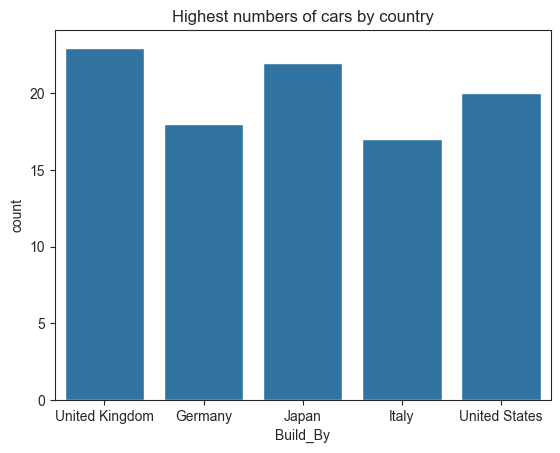

In [122]:
#Which country has the highest number of cars in the dataset?
sns.countplot(data=df, x="Build_By")
sns.set_style("ticks")
plt.title("Highest numbers of cars by country") 

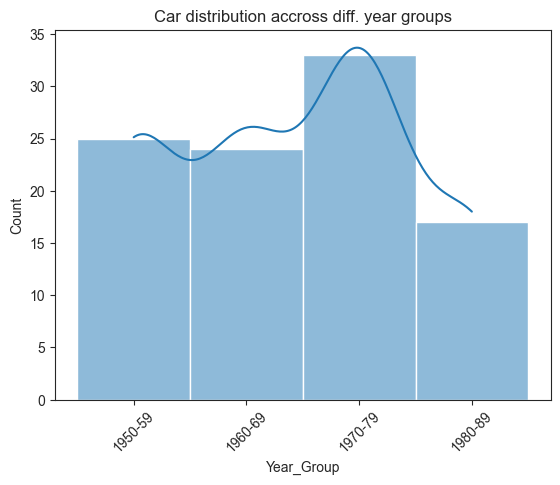

In [123]:
#How are the cars distributed across different manufacturing years?
bins = [1950, 1960, 1970, 1980, 1990, 2000]
labels = ["1950-59", "1960-69", "1970-79", "1980-89",
          "1990-99"]

df["Year_Group"] = pd.cut(
    df["Year"],
    bins=bins,
    labels=labels
)
sns.histplot(data=df, x="Year_Group" ,kde=True)
plt.xticks(rotation=45)
# sns.set_style("ticks")
plt.title("Car distribution accross diff. year groups")
plt.show()

Text(0.5, 1.0, 'Countries with the highest average mileage cars')

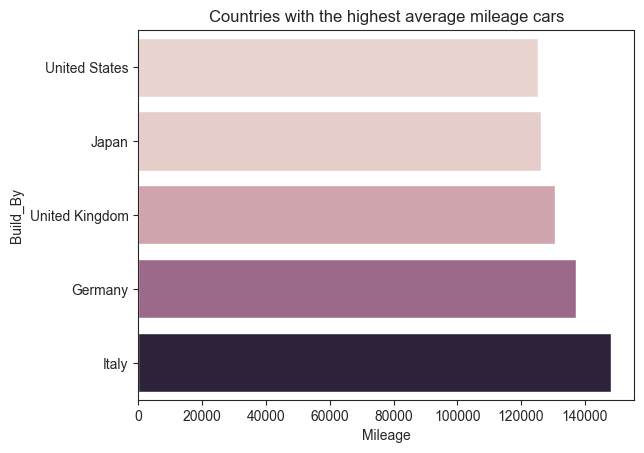

In [124]:
#Which country has the highest average mileage?
good_mileage = df.groupby("Build_By")['Mileage'].mean().reset_index().sort_values('Mileage')
sns.barplot(data=good_mileage,x="Mileage", y="Build_By", hue="Mileage" ,legend=False)
plt.title("Countries with the highest average mileage cars")

In [125]:
top_10 = df.sort_values(
    by="Mileage",
    ascending=False
).head(10)

Text(0.5, 1.0, 'Top 10 cars with highest mileages')

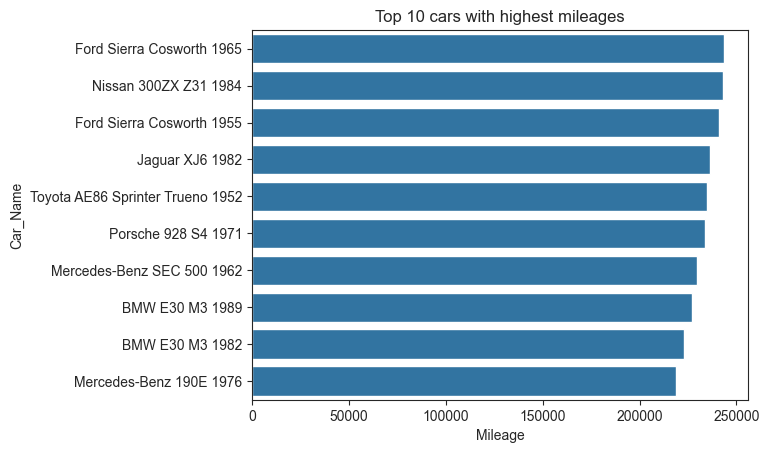

In [126]:
sns.barplot(data=top_10, x="Mileage" ,y="Car_Name")
plt.title("Top 10 cars with highest mileages")